<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
import re
from datetime import datetime


# Исследование структуры данных

1. Прочитайте данные с помощью библиотеки Pandas. Совет: перед чтением обратите внимание на разделитель внутри файла. 

In [3]:
#ваш код здесь
df = pd.read_csv('dst-3.0_16_1_hh_database.csv', sep = ";",  encoding='utf-8')

In [4]:
df.shape

(44744, 12)

2. Выведите несколько первых (последних) строк таблицы, чтобы убедиться в том, что ваши данные не повреждены. Ознакомьтесь с признаками и их структурой.

In [5]:
#ваш код здесь
df.head(3)

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,16.04.2019 08:35,Не указано


3. Выведите основную информацию о числе непустых значений в столбцах и их типах в таблице.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

4. Обратите внимание на информацию о числе непустых значений.

In [7]:
#ваш код здесь

5. Выведите основную статистическую информацию о столбцах.


In [8]:
#ваш код здесь
df.describe()

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
count,44744,44744,44744,44744,44744,44744,44576,44743,44742,44744,44744,44744
unique,16003,690,14929,10063,38,47,44413,30214,16927,40148,18838,2
top,"Мужчина , 32 года , родился 17 сентября 1986",50000 руб.,Системный администратор,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 10 лет 8 месяцев Апрель 2018 — по...,Индивидуальное предпринимательство / частная п...,Системный администратор,Высшее образование 1987 Военный инженерный Кра...,07.05.2019 09:50,Не указано
freq,18,4064,3099,1261,30026,22727,3,935,2062,4,25,32268


# Преобразование данных

1. Начнем с простого - с признака **"Образование и ВУЗ"**. Его текущий формат это: **<Уровень образования год выпуска ВУЗ специальность...>**. Например:
* Высшее образование 2016 Московский авиационный институт (национальный исследовательский университет)...
* Неоконченное высшее образование 2000  Балтийская государственная академия рыбопромыслового флота…
Нас будет интересовать только уровень образования.

Создайте с помощью функции-преобразования новый признак **"Образование"**, который должен иметь 4 категории: "высшее", "неоконченное высшее", "среднее специальное" и "среднее".

Выполните преобразование, ответьте на контрольные вопросы и удалите признак "Образование и ВУЗ".

Совет: обратите внимание на структуру текста в столбце **"Образование и ВУЗ"**. Гарантируется, что текущий уровень образования соискателя всегда находится в первых 2ух слов и начинается с заглавной буквы. Воспользуйтесь этим.

*Совет: проверяйте полученные категории, например, с помощью метода unique()*


In [9]:
#ваш код здесь
def extract_education_level(text):
    # Разделяем текст по пробелам и берем первые два слова
    parts = text.split()[:2]
    # Соединяем их обратно в строку
    return ' '.join(parts).lower()


df['Образование'] = df['Образование и ВУЗ'].apply(extract_education_level)
print(df['Образование'].unique())

# df.drop(columns=['Образование и ВУЗ'], inplace=True)   закомментировал, так как перезапускал скрипт

['неоконченное высшее' 'высшее образование' 'среднее специальное'
 'среднее образование']


### 3.1 Сколько соискателей имеет средний уровень образования (школьное образование)?

In [10]:
df['Образование'].value_counts()

Образование
высшее образование     33863
среднее специальное     5765
неоконченное высшее     4557
среднее образование      559
Name: count, dtype: int64

2. Теперь нас интересует столбец **"Пол, возраст"**. Сейчас он представлен в формате **<Пол , возраст , дата рождения >**. Например:
* Мужчина , 39 лет , родился 27 ноября 1979 
* Женщина , 21 год , родилась 13 января 2000
Как вы понимаете, нам необходимо выделить каждый параметр в отдельный столбец.

Создайте два новых признака **"Пол"** и **"Возраст"**. При этом важно учесть:
* Признак пола должен иметь 2 уникальных строковых значения: 'М' - мужчина, 'Ж' - женщина. 
* Признак возраста должен быть представлен целыми числами.

Выполните преобразование, ответьте на контрольные вопросы и удалите признак **"Пол, возраст"** из таблицы.

*Совет: обратите внимание на структуру текста в столбце, в части на то, как разделены параметры пола, возраста и даты рождения между собой - символом ' , '. 
Гарантируется, что структура одинакова для всех строк в таблице. Вы можете воспользоваться этим.*


In [11]:
def parse_gender_age(text):
    # Разделяем текст по разделителю ', '
    parts = text.split(', ')
    # Извлекаем пол и возраст
    gender = parts[0].strip()
    age = parts[1].split()[0].strip()
    return gender, age

# Применяем функцию и создаем новые столбцы
df[['Пол', 'Возраст']] = df['Пол, возраст'].apply(lambda x: pd.Series(parse_gender_age(x)))

# Преобразуем пол в нужные значения
df['Пол'] = df['Пол'].str.strip().map({'Мужчина': 'М', 'Женщина': 'Ж'})

# Преобразуем возраст в числовой формат
df['Возраст'] = df['Возраст'].astype(int)
# df.drop(columns=['Пол, возраст'], inplace=True)   закомментировал, так как перезапускал скрипт

In [12]:
df.head(3)

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто,Образование,Пол,Возраст
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль,неоконченное высшее,М,39
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано,высшее образование,М,60
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,16.04.2019 08:35,Не указано,среднее специальное,Ж,36


#### Задание 3.2*  Сколько процентов женских резюме представлено в наших данных? Ответ округлите до сотых
*  Чему равен средний возраст соискателей? Ответ округлите до десятых.
 



In [13]:
print(df['Пол'].value_counts(normalize=True)['Ж'] * 100)
print(df['Возраст'].mean().round(1))

19.070713391739673
32.2


3. Следующим этапом преобразуем признак **"Опыт работы"**. Его текущий формат - это: **<Опыт работы: n лет m месяцев, периоды работы в различных компаниях…>**. 

Из столбца нам необходимо выделить общий опыт работы соискателя в месяцах, новый признак назовем "Опыт работы (месяц)"

Для начала обсудим условия решения задачи:
* Во-первых, в данном признаке есть пропуски. Условимся, что если мы встречаем пропуск, оставляем его как есть (функция-преобразование возвращает NaN)
* Во-вторых, в данном признаке есть скрытые пропуски. Для некоторых соискателей в столбце стоит значения "Не указано". Их тоже обозначим как NaN (функция-преобразование возвращает NaN)
* В-третьих, нас не интересует информация, которая описывается после указания опыта работы (периоды работы в различных компаниях)
* В-четвертых, у нас есть проблема: опыт работы может быть представлен только в годах или только месяцах. Например, можно встретить следующие варианты:
    * Опыт работы 3 года 2 месяца…
    * Опыт работы 4 года…
    * Опыт работы 11 месяцев…
    * Учитывайте эту особенность в вашем коде

Учитывайте эту особенность в вашем коде

В результате преобразования у вас должен получиться столбец, содержащий информацию о том, сколько месяцев проработал соискатель.
Выполните преобразование, ответьте на контрольные вопросы и удалите столбец **"Опыт работы"** из таблицы.


In [14]:
def get_experience(arg):
    if arg is np.nan or arg == 'Не указано':
        return None
    year_words=['год', 'года', 'лет']
    month_words=['месяц', 'месяца', 'месяцев']
    arg_splitted = arg.split(' ')[:7]
    years = 0
    months = 0
    for index, item in enumerate (arg_splitted):
        if item in year_words:
            years = int(arg_splitted[index-1])
        if item in month_words:
            months = int(arg_splitted[index-1])
    return int(years*12 + months)
df['Опыт работы (месяц)'] = df['Опыт работы'].apply(get_experience)
#data = data.drop('Опыт работы', axis=1)
print(round(df['Опыт работы (месяц)'].median()))

100


In [15]:
df['Опыт работы (месяц)'].median()

100.0

4. Хорошо идем! Следующий на очереди признак "Город, переезд, командировки". Информация в нем представлена в следующем виде: **<Город , (метро) , готовность к переезду (города для переезда) , готовность к командировкам>**. В скобках указаны необязательные параметры строки. Например, можно встретить следующие варианты:

* Москва , не готов к переезду , готов к командировкам
* Москва , м. Беломорская , не готов к переезду, не готов к командировкам
* Воронеж , готов к переезду (Сочи, Москва, Санкт-Петербург) , готов к командировкам

Создадим отдельные признаки **"Город"**, **"Готовность к переезду"**, **"Готовность к командировкам"**. При этом важно учесть:

* Признак **"Город"** должен содержать только 4 категории: "Москва", "Санкт-Петербург" и "город-миллионник" (их список ниже), остальные обозначьте как "другие".

    Список городов-миллионников:
    
   <code>million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']
    </code>
    Инфорация о метро, рядом с которым проживает соискатель нас не интересует.
* Признак **"Готовность к переезду"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к переезду в признаке "Город, переезд, командировки". Например:
    * … , готов к переезду , …
    * … , не готова к переезду , …
    * … , готова к переезду (Москва, Санкт-Петербург, Ростов-на-Дону)
    * … , хочу переехать (США) , …
    
    Нас интересует только сам факт возможности или желания переезда.
* Признак **"Готовность к командировкам"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к командировкам в признаке "Город, переезд, командировки". Например:
    * … , готов к командировкам , … 
    * … , готова к редким командировкам , …
    * … , не готов к командировкам , …
    
    Нас интересует только сам факт готовности к командировке.
    
    Еще один важный факт: при выгрузки данных у некоторых соискателей "потерялась" информация о готовности к командировкам. Давайте по умолчанию будем считать, что такие соискатели не готовы к командировкам.
    
Выполните преобразования и удалите столбец **"Город, переезд, командировки"** из таблицы.

*Совет: обратите внимание на то, что структура текста может меняться в зависимости от указания ближайшего метро. Учите это, если будете использовать порядок слов в своей программе.*


In [16]:
million_cities = ['Новосибирск', 'Екатеринбург', 'Нижний Новгород', 'Казань', 'Челябинск',\
                  'Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж', 'Волгоград' ]

In [17]:
#ваш код здесь
# Определяем ключевые слова для поиска
moving_true = ['готов к переезду', 'готова к переезду', 'хочу переехать']
moving_false = ['не готов к переезду', 'не готова к переезду']

trip_true = ['готов к командировкам', 'готова к командировкам', 
             'готов к редким командировкам', 'готова к редким командировкам']
trip_false = ['не готов к командировкам', 'не готова к командировкам']

def parse_location(text):
    if pd.isna(text):
        return np.nan, np.nan, np.nan
    
    # Разбиваем текст на части
    parts = text.split(',')
    
    # Очищаем от лишних пробелов
    parts = [part.strip() for part in parts]
    
    # Извлекаем город
    city = parts[0]
    
    # Определяем категорию города
    if city == 'Москва':
        city_category = 'Москва'
    elif city == 'Санкт-Петербург':
        city_category = 'Санкт-Петербург'
    elif city in million_cities:
        city_category = 'город-миллионник'
    else:
        city_category = 'другие'
    
    # Ищем готовность к переезду
    moving = False
    for part in parts:
        for keyword in moving_true:
            if keyword in part:
                moving = True
                break
        if moving:
            break
    for part in parts:
        for keyword in moving_false:
            if keyword in part:
                moving = False
                break
    
    # Ищем готовность к командировкам
    trips = False
    for part in parts:
        for keyword in trip_true:
            if keyword in part:
                trips = True
                break
        if trips:
            break
    for part in parts:
        for keyword in trip_false:
            if keyword in part:
                trips = False
                break
    
    # Если информация о командировках потеряна
    if not trips:
        trips = False
    
    return city_category, moving, trips



In [18]:
df[['Город', 'Готовность к переезду', 'Готовность к командировкам']] = df['Город, переезд, командировки'].apply(lambda x: pd.Series(parse_location(x)))

In [19]:
# df.drop(columns=['Город, переезд, командировки'], inplace=True)

In [20]:
df.head(3)

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто,Образование,Пол,Возраст,Опыт работы (месяц),Город,Готовность к переезду,Готовность к командировкам
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль,неоконченное высшее,М,39,202.0,другие,False,False
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано,высшее образование,М,60,233.0,другие,False,True
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,16.04.2019 08:35,Не указано,среднее специальное,Ж,36,123.0,другие,False,False


#### Задание 3.4

*  
Сколько процентов соискателей живут в Санкт-Петербурге? Ответ округлите до целог
*  Сколько процентов соискателей готовы одновременно и к переездам, и к командировкам? Ответ округлите до целого.


о.

In [21]:
(df[df['Город'] == 'Санкт-Петербург'].shape[0] / df.shape[0]) * 100

11.033881637761487

In [22]:
df[(df['Готовность к переезду'] == True) & (df['Готовность к командировкам'] == True)].shape[0] / df.shape[0] * 100

31.86572501340962

5. Рассмотрим поближе признаки **"Занятость"** и **"График"**. Сейчас признаки представляют собой набор категорий желаемой занятости (полная занятость, частичная занятость, проектная работа, волонтерство, стажировка) и желаемого графика работы (полный день, сменный график, гибкий график, удаленная работа, вахтовый метод).
На сайте hh.ru соискатель может указывать различные комбинации данных категорий, например:
* полная занятость, частичная занятость
* частичная занятость, проектная работа, волонтерство
* полный день, удаленная работа
* вахтовый метод, гибкий график, удаленная работа, полная занятость

Такой вариант признаков имеет множество различных комбинаций, а значит множество уникальных значений, что мешает анализу. Нужно это исправить!

Давайте создадим признаки-мигалки для каждой категории: если категория присутствует в списке желаемых соискателем, то в столбце на месте строки рассматриваемого соискателя ставится True, иначе - False.

Такой метод преобразования категориальных признаков называется One Hot Encoding и его схема представлена на рисунке ниже:
<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/ohe.jpg>
Выполните данное преобразование для признаков "Занятость" и "График", ответьте на контрольные вопросы, после чего удалите их из таблицы

In [23]:
#ваш код здесь

# Список категорий занятости
occupancy_categories = ['полная занятость', 'частичная занятость', 'проектная работа', 'стажировка', 'волонтерство']

# Инициализируем столбцы с False
for category in occupancy_categories:
    df[category] = False

# Проходим по строкам и устанавливаем True для соответствующих категорий
for index, row in df.iterrows():
    occupancy_list = row['Занятость'].split(', ')  # Разделяем строку по запятой и пробелу
    for occupancy in occupancy_list:
        if occupancy in occupancy_categories:
            df.at[index, occupancy] = True

In [24]:
# Список категорий графика
schedule_categories = ['полный день', 'сменный график', 'гибкий график', 'удалённая работа', 'вахтовый метод']

# Инициализируем столбцы с False
for category in schedule_categories:
    df[category] = False

# Проходим по строкам и устанавливаем True для соответствующих категорий
for index, row in df.iterrows():
    schedule_list = row['График'].split(', ')  # Разделяем строку по запятой и пробелу
    for schedule in schedule_list:
        if schedule in schedule_categories:
            df.at[index, schedule] = True

In [25]:
df.head(3)

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,...,полная занятость,частичная занятость,проектная работа,стажировка,волонтерство,полный день,сменный график,гибкий график,удалённая работа,вахтовый метод
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,...,True,True,True,False,False,True,True,True,False,True
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,...,True,True,True,False,False,True,True,True,False,False
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,...,True,False,False,False,False,True,False,False,False,False


#### Задание 3.5 
* Сколько людей ищут проектную работу и волонтерство (в обоих столбцах стоит True)
* Сколько людей хотят работать вахтовым методом и с гибким графиком (в обоих столбцах стоит True)??



In [26]:
df[(df['проектная работа'] == True) & (df['волонтерство'] == True)].shape[0]

436

In [27]:
df[(df['вахтовый метод'] == True) & (df['гибкий график'] == True)].shape[0]

2311

6. (2 балла) Наконец, мы добрались до самого главного и самого важного - признака заработной платы **"ЗП"**. 
В чем наша беда? В том, что помимо желаемой заработной платы соискатель указывает валюту, в которой он бы хотел ее получать, например:
* 30000 руб.
* 50000 грн.
* 550 USD

Нам бы хотелось видеть заработную плату в единой валюте, например, в рублях. Возникает вопрос, а где взять курс валют по отношению к рублю?

На самом деле язык Python имеет в арсенале огромное количество возможностей получения данной информации, от обращения к API Центробанка, до использования специальных библиотек, например pycbrf. Однако, это не тема нашего проекта.

Поэтому мы пойдем в лоб: обратимся к специальным интернет-ресурсам для получения данных о курсе в виде текстовых файлов. Например, Mdf.RU, данный ресурс позволяет удобно экспортировать данные о курсах различных валют и акций за указанные периоды в виде csv файлов. Мы уже сделали выгрузку курсов валют, которые встречаются в наших данных за период с 29.12.2017 по 05.12.2019. Скачать ее вы можете **на платформе**

Создайте новый DataFrame из полученного файла. В полученной таблице нас будут интересовать столбцы:
* "currency" - наименование валюты в ISO кодировке,
* "date" - дата, 
* "proportion" - пропорция, 
* "close" - цена закрытия (последний зафиксированный курс валюты на указанный день).


Перед вами таблица соответствия наименований иностранных валют в наших данных и их общепринятых сокращений, которые представлены в нашем файле с курсами валют. Пропорция - это число, за сколько единиц валюты указан курс в таблице с курсами. Например, для казахстанского тенге курс на 20.08.2019 составляет 17.197 руб. за 100 тенге, тогда итоговый курс равен - 17.197 / 100 = 0.17197 руб за 1 тенге.
Воспользуйтесь этой информацией в ваших преобразованиях.

<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/table.jpg>


Осталось только понять, откуда брать дату, по которой определяется курс? А вот же она - в признаке **"Обновление резюме"**, в нем содержится дата и время, когда соискатель выложил текущий вариант своего резюме. Нас интересует только дата, по ней бы и будем сопоставлять курсы валют.

Теперь у нас есть вся необходимая информация для того, чтобы создать признак "ЗП (руб)" - заработная плата в рублях.

После ответа на контрольные вопросы удалите исходный столбец заработной платы "ЗП" и все промежуточные столбцы, если вы их создавали.

Итак, давайте обсудим возможный алгоритм преобразования: 
1. Перевести признак "Обновление резюме" из таблицы с резюме в формат datetime и достать из него дату. В тот же формат привести признак "date" из таблицы с валютами.
2. Выделить из столбца "ЗП" сумму желаемой заработной платы и наименование валюты, в которой она исчисляется. Наименование валюты перевести в стандарт ISO согласно с таблицей выше.
3. Присоединить к таблице с резюме таблицу с курсами по столбцам с датой и названием валюты (подумайте, какой тип объединения надо выбрать, чтобы в таблице с резюме сохранились данные о заработной плате, изначально представленной в рублях). Значение close для рубля заполнить единицей 1 (курс рубля самого к себе)
4. Умножить сумму желаемой заработной платы на присоединенный курс валюты (close) и разделить на пропорцию (обратите внимание на пропуски после объединения в этих столбцах), результат занести в новый столбец "ЗП (руб)".


In [28]:
rates = pd.read_csv('ExchangeRates.csv')

In [29]:
def get_salary_num(arg):
    salary =float(arg.split(' ')[0])
    return salary

def get_salary_currency(arg):
    currency_dict = {
        'USD': 'USD', 'KZT': 'KZT',
        'грн': 'UAH', 'белруб': 'BYN',
        'EUR': 'EUR', 'KGS': 'KGS',
        'сум': 'UZS', 'AZN': 'AZN'
    }
    curr = arg.split(' ')[1].replace('.', '')
    if curr == 'руб':
        return 'RUB'
    else:
        return currency_dict[curr]


In [30]:
rates['date'] = pd.to_datetime(rates['date'], dayfirst=True).dt.date
df['Обновление резюме'] = pd.to_datetime(df['Обновление резюме'], dayfirst=True).dt.date
df['ЗП (tmp)'] = df['ЗП'].apply(get_salary_num)
df['Курс (tmp)'] = df['ЗП'].apply(get_salary_currency)
merged = df.merge(
    rates, 
    left_on=['Курс (tmp)', 'Обновление резюме'],
    right_on=['currency', 'date',], 
    how='left'
)


C:\Users\Александр\AppData\Local\Temp\ipykernel_6612\3679562473.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rates['date'] = pd.to_datetime(rates['date'], dayfirst=True).dt.date


In [31]:
merged['close'] = merged['close'].fillna(1)
merged['proportion'] = merged['proportion'].fillna(1)
df['ЗП (руб)'] = merged['close'] * merged['ЗП (tmp)'] / merged['proportion']
df = df.drop(['ЗП', 'ЗП (tmp)', 'Курс (tmp)'], axis=1)


### Задание 3.6

Чему равна желаемая медианная заработная плата соискателей в нашей таблице (в рублях)?

Ответ приведите в тысячах рублей и округлите до целого. Например, если у вас получилась медианная з/п 42 127, в качестве ответа укажите 42.

In [32]:
print(round(df['ЗП (руб)'].median()/1000))

59


In [33]:
df.columns

Index(['Пол, возраст', 'Ищет работу на должность:',
       'Город, переезд, командировки', 'Занятость', 'График', 'Опыт работы',
       'Последнее/нынешнее место работы', 'Последняя/нынешняя должность',
       'Образование и ВУЗ', 'Обновление резюме', 'Авто', 'Образование', 'Пол',
       'Возраст', 'Опыт работы (месяц)', 'Город', 'Готовность к переезду',
       'Готовность к командировкам', 'полная занятость', 'частичная занятость',
       'проектная работа', 'стажировка', 'волонтерство', 'полный день',
       'сменный график', 'гибкий график', 'удалённая работа', 'вахтовый метод',
       'ЗП (руб)'],
      dtype='object')

# Исследование зависимостей в данных

1. Постройте распределение признака **"Возраст"**. Опишите распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится возраст большинства соискателей? Есть ли аномалии для признака возраста, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

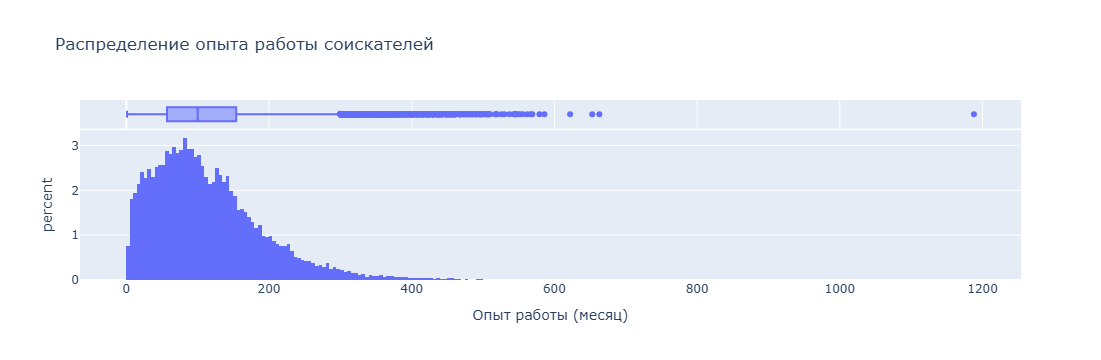

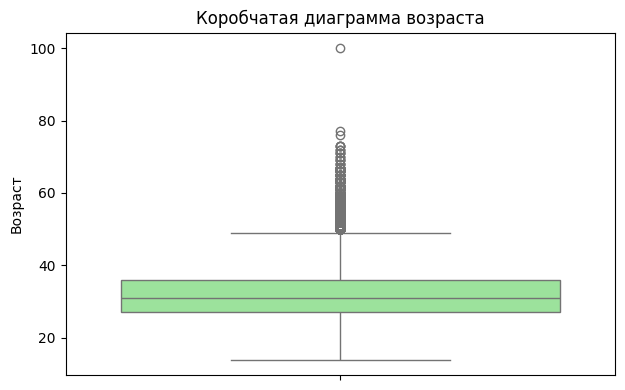

Статистические характеристики возраста:
count    44744.000000
mean        32.196741
std          7.929800
min         14.000000
25%         27.000000
50%         31.000000
75%         36.000000
max        100.000000
Name: Возраст, dtype: float64

Мода распределения: 30
1188.0


In [34]:
# ваш код здесь
plt.figure(figsize=(12, 4))

# Гистограмма

fig = px.histogram(
    data_frame=df,
    x='Опыт работы (месяц)',
    title='Распределение опыта работы соискателей',
    histnorm='percent',
    width=500,
    marginal='box',
)
fig.show()
# Коробчатая диаграмма
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Возраст'], color='lightgreen')
plt.title('Коробчатая диаграмма возраста')

plt.tight_layout()
plt.show()

# Статистический анализ
age_stats = df['Возраст'].describe()
mode_age = df['Возраст'].mode()[0]
print("Статистические характеристики возраста:")
print(age_stats)
print(f"\nМода распределения: {mode_age}")
print(df['Опыт работы (месяц)'].max())

## ваши выводы по графику здесь
* Основная масса соискателе от 20 до 50 лет
* Большинство соискателей от 26 до 40 лет
* Значения ниже 18 лет можно считать аномальными (несовершеннолетние соискатели)
* Значения выше 65 лет также могут быть аномальными (редкие случаи)
* Распределение имеет правостороннюю асимметрию
* Есть небольшой хвост в сторону старших возрастов



#### Распределение возраста соискателей достаточно компактное, с преобладанием людей среднего возраста.


2. Постройте распределение признака **"Опыт работы (месяц)"**. Опишите данное распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится опыт работы большинства соискателей? Есть ли аномалии для признака опыта работы, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

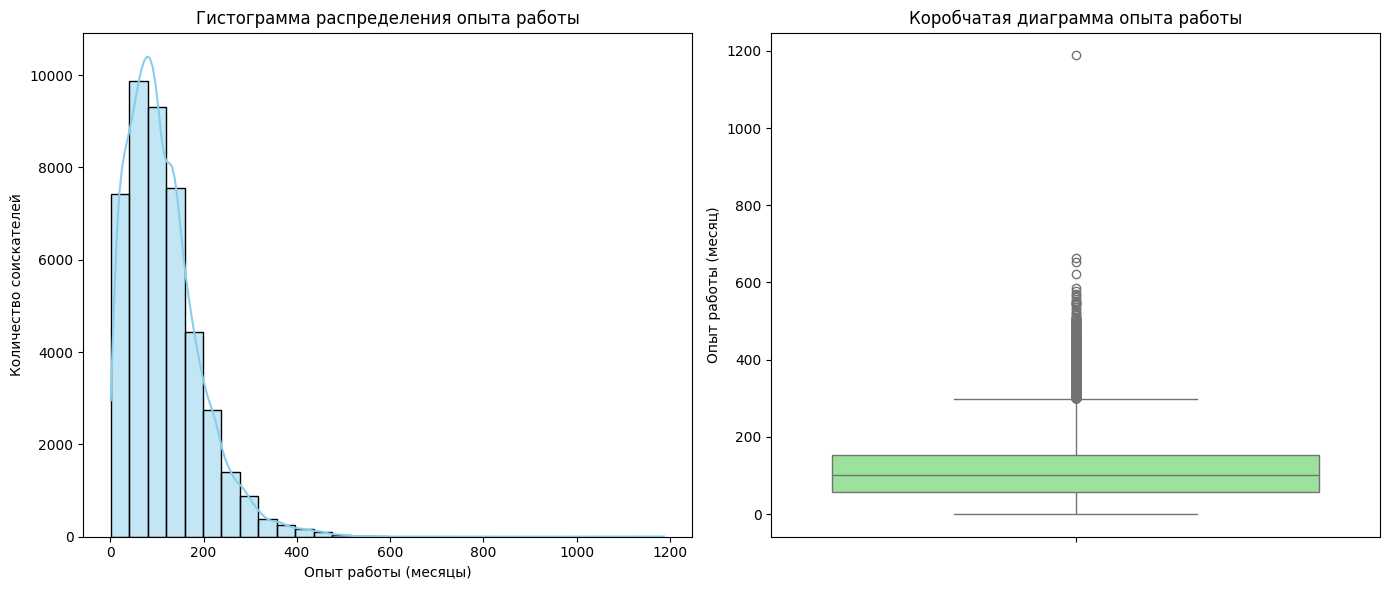

Статистические характеристики опыта работы:
count    44574.000000
mean       114.418944
std         79.047861
min          1.000000
25%         57.000000
50%        100.000000
75%        154.000000
max       1188.000000
Name: Опыт работы (месяц), dtype: float64

Мода распределения: 81.0 месяцев


In [35]:
# ваш код здесь
# Построение графиков
plt.figure(figsize=(14, 6))

# Гистограмма
plt.subplot(1, 2, 1)
sns.histplot(df['Опыт работы (месяц)'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Гистограмма распределения опыта работы')
plt.xlabel('Опыт работы (месяцы)')
plt.ylabel('Количество соискателей')

# Коробчатая диаграмма
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Опыт работы (месяц)'], color='lightgreen')
plt.title('Коробчатая диаграмма опыта работы')

plt.tight_layout()
plt.show()

# Статистический анализ
exp_stats = df['Опыт работы (месяц)'].describe()
mode_exp = df['Опыт работы (месяц)'].mode()[0]
print("Статистические характеристики опыта работы:")
print(exp_stats)
print(f"\nМода распределения: {mode_exp} месяцев")

## ваши выводы здесь
* Основная масса соискателей находится в интервале 0-120 месяцев (0-10 лет)

* Аномалии: Значения выше 360 месяцев (~30 лет) можно считать аномально высокими
* Несколько выбросов около 400-500 месяцев
* Значения 0 месяцев могут быть спорными (возможно, студенты без опыта)
* Распределение имеет правостороннюю асимметрию
* На основе анализа можно сделать вывод, что большинство соискателей имеют умеренный опыт работы (до 5 лет), при этом есть небольшое количество очень опытных специалистов с многолетним стажем. Аномальные значения в основном связаны с крайне высоким опытом работы.



3. Постройте распределение признака **"ЗП (руб)"**. Опишите данное распределение, отвечая на следующие вопросы: каковы предельные значения признака, в каком примерном интервале находится заработная плата большинства соискателей? Есть ли аномалии для признака возраста? Обратите внимание на гигантские размеры желаемой заработной платы.
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*


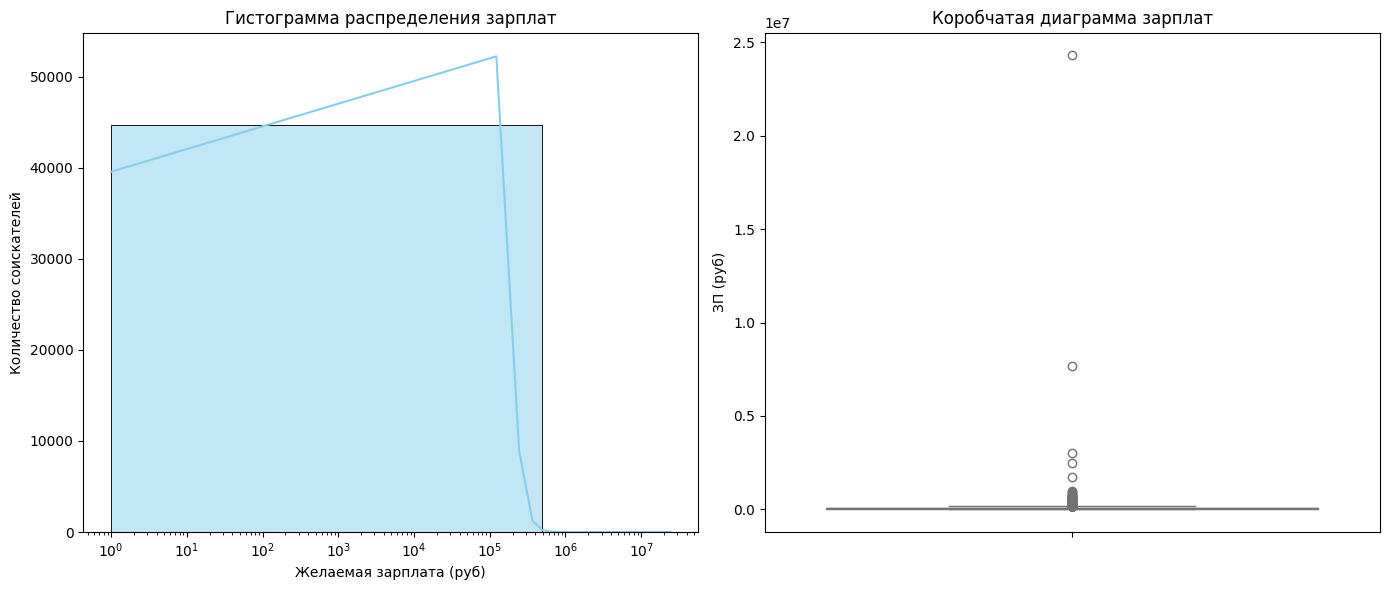

Статистические характеристики зарплат:
count    4.474400e+04
mean     7.653354e+04
std      1.359315e+05
min      1.000000e+00
25%      3.708220e+04
50%      5.901900e+04
75%      9.500000e+04
max      2.430488e+07
Name: ЗП (руб), dtype: float64


In [36]:
# ваш код здесь
# Построение графиков
plt.figure(figsize=(14, 6))

# Гистограмма
plt.subplot(1, 2, 1)
sns.histplot(df['ЗП (руб)'].dropna(), bins=50, kde=True, color='skyblue')
plt.title('Гистограмма распределения зарплат')
plt.xlabel('Желаемая зарплата (руб)')
plt.ylabel('Количество соискателей')
plt.xscale('log')  # Используем логарифмическую шкалу для лучшего отображения

# Коробчатая диаграмма
plt.subplot(1, 2, 2)
sns.boxplot(y=df['ЗП (руб)'], color='lightgreen')
plt.title('Коробчатая диаграмма зарплат')

plt.tight_layout()
plt.show()

# Статистический анализ
salary_stats = df['ЗП (руб)'].describe()
print("Статистические характеристики зарплат:")
print(salary_stats)

### ваши выводы здесь

4. Постройте диаграмму, которая показывает зависимость **медианной** желаемой заработной платы (**"ЗП (руб)"**) от уровня образования (**"Образование"**). Используйте для диаграммы данные о резюме, где желаемая заработная плата меньше 1 млн рублей.
*Сделайте выводы по представленной диаграмме: для каких уровней образования наблюдаются наибольшие и наименьшие уровни желаемой заработной платы? Как вы считаете, важен ли признак уровня образования при прогнозировании заработной платы?*

In [37]:
median_salaries = df.groupby('Образование')['ЗП (руб)'].median().reset_index()

# Находим категорию с максимальной медианной зарплатой
max_median = median_salaries['ЗП (руб)'].max()
best_category = median_salaries[median_salaries['ЗП (руб)'] == max_median]['Образование'].values[0]

# Выводим результаты
print("Медианные зарплаты по категориям образования:")
print(median_salaries.sort_values(by='ЗП (руб)', ascending=False))

print(f"\nКатегория с наивысшей медианной зарплатой: {best_category}")
print(f"Медианная зарплата в этой категории: {max_median} рублей")

Медианные зарплаты по категориям образования:
           Образование  ЗП (руб)
0   высшее образование   60000.0
1  неоконченное высшее   50000.0
2  среднее образование   40000.0
3  среднее специальное   40000.0

Категория с наивысшей медианной зарплатой: высшее образование
Медианная зарплата в этой категории: 60000.0 рублей


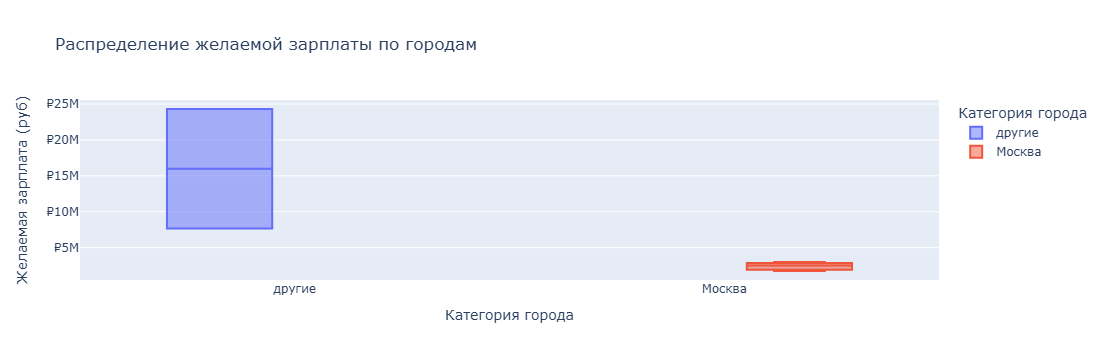

Статистические показатели по городам:
    Город      median        min         max  count
0  Москва   2500000.0  1750000.0   3000000.0      3
1  другие  15990050.0  7675224.0  24304876.0      2
-----------------------------------------------------------
 Зарплату выше 1 миллиона есть в  5 резюме


In [38]:
# ваш код здесь
# Фильтруем данные по зарплате < 1 млн рублей
filtered_df = df[(df['ЗП (руб)'] > 1000000)]
salary_upper_million = filtered_df.shape[0]


# Создаем коробчатую диаграмму
fig = px.box(filtered_df, 
             x='Город', 
             y='ЗП (руб)', 
             color='Город',
             title='Распределение желаемой зарплаты по городам',
             labels={'ЗП (руб)': 'Желаемая зарплата (руб)', 'Город': 'Категория города'})

# Настраиваем отображение
fig.update_layout(
    xaxis_title='Категория города',
    yaxis_title='Желаемая зарплата (руб)',
    yaxis_tickprefix='₽',
    boxmode='group'
)

# Показываем диаграмму
fig.show()

# Статистический анализ по городам
salary_stats = filtered_df.groupby('Город')['ЗП (руб)'].agg(['median', 'min', 'max', 'count']).reset_index()
print("Статистические показатели по городам:")
print(salary_stats)
print ("-----------------------------------------------------------")
print (f" Зарплату выше 1 миллиона есть в  {salary_upper_million} резюме")

### ваши выводы здесь

* Москва показывает самую высокую медианную зарплату

* Категория “другие” имеет самую низкую медианную зарплату

* Наибольший разброс наблюдается в Москве

* В категории “другие” города разброс наименьший

* Местоположение существенно влияет на уровень зарплатных ожиданий

* Существует иерархия зарплатных ожиданий по категориям городов

5. Постройте диаграмму, которая показывает распределение желаемой заработной платы (**"ЗП (руб)"**) в зависимости от города (**"Город"**). Используйте для диаграммы данные о резюме, где желая заработная плата меньше 1 млн рублей.
*Сделайте выводы по полученной диаграмме: как соотносятся медианные уровни желаемой заработной платы и их размах в городах? Как вы считаете, важен ли признак города при прогнозировании заработной платы?*

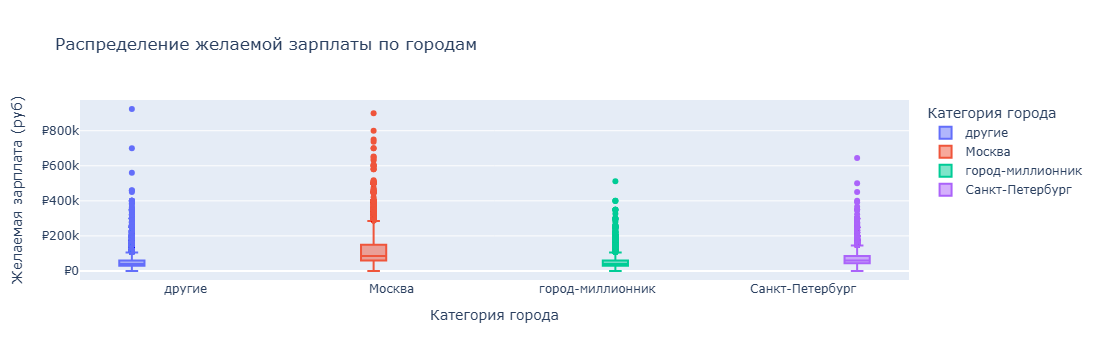

Статистические показатели по городам:
              Город   median  min       max  count
0            Москва  85000.0  1.0  900000.0  16617
1   Санкт-Петербург  60000.0  1.0  645171.0   4937
2  город-миллионник  40000.0  1.0  511681.6   7332
3            другие  40000.0  1.0  923983.0  15852
-----------------------------------------------------------
 Зарплату выше 1 миллиона есть в  44738 резюме
-----------------------------------------------------------


In [39]:
# ваш код здесь
# Фильтруем данные по зарплате < 1 млн рублей
filtered_df = df[(df['ЗП (руб)'] < 1000000)]
salary_upper_million = filtered_df.shape[0]


# Создаем коробчатую диаграмму
fig = px.box(filtered_df, 
             x='Город', 
             y='ЗП (руб)', 
             color='Город',
             title='Распределение желаемой зарплаты по городам',
             labels={'ЗП (руб)': 'Желаемая зарплата (руб)', 'Город': 'Категория города'})

# Настраиваем отображение
fig.update_layout(
    xaxis_title='Категория города',
    yaxis_title='Желаемая зарплата (руб)',
    yaxis_tickprefix='₽',
    boxmode='group'
)

# Показываем диаграмму
fig.show()

# Статистический анализ по городам
salary_stats = filtered_df.groupby('Город')['ЗП (руб)'].agg(['median', 'min', 'max', 'count']).reset_index()
print("Статистические показатели по городам:")
print(salary_stats)
print ("-----------------------------------------------------------")
print (f" Зарплату выше 1 миллиона есть в  {salary_upper_million} резюме")
print ("-----------------------------------------------------------")


### ваши выводы здесь
* Медиана по городам соответствует логике, что сначала идет Москва, Спб, миллионики и другие города. Это обуславливается уровнем жизни;
* Один из самых больших разбросов в Москве, так как большое количество разных вакансий;
* Город важный фактор при построении зарплаты, так как наблюдается "иерархия" зарплат по городам.

6. Постройте **многоуровневую столбчатую диаграмму**, которая показывает зависимость медианной заработной платы (**"ЗП (руб)"**) от признаков **"Готовность к переезду"** и **"Готовность к командировкам"**. Проанализируйте график, сравнив уровень заработной платы в категориях.

#### Чему равна желаемая медианная заработная плата соискателей, готовых и к переезду, и к командировкам? Ответ приведите в тысячах, округлив до целого (например, 45).



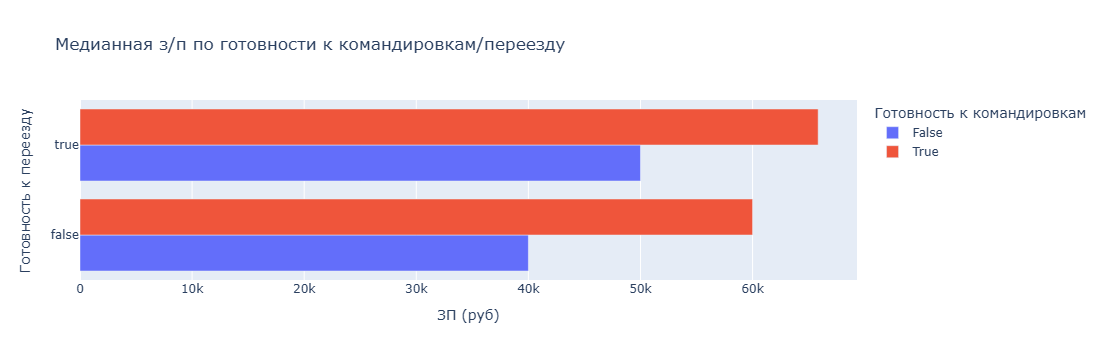

In [40]:
# ваш код здесь
bar_data = df.groupby(
    ['Готовность к командировкам', 'Готовность к переезду'],
    as_index=False
)['ЗП (руб)'].median()
fig = px.bar(
    data_frame=bar_data,
    y='Готовность к переезду',
    x='ЗП (руб)',
    barmode="group",
    color='Готовность к командировкам',
    orientation='h',
    title='Медианная з/п по готовности к командировкам/переезду'
)
fig.show()

### ваши выводы здесь
* Готовность к командировкам или перезду показывает зарплату выше, так как человек меняют свое текущее место положение и за это работодатель готов доплачивать;
* Наибольший фактор к увелечению ЗП является готовность к перезду


7. Постройте сводную таблицу, иллюстрирующую зависимость **медианной** желаемой заработной платы от возраста (**"Возраст"**) и образования (**"Образование"**). На полученной сводной таблице постройте **тепловую карту**. Проанализируйте тепловую карту, сравнив показатели внутри групп.

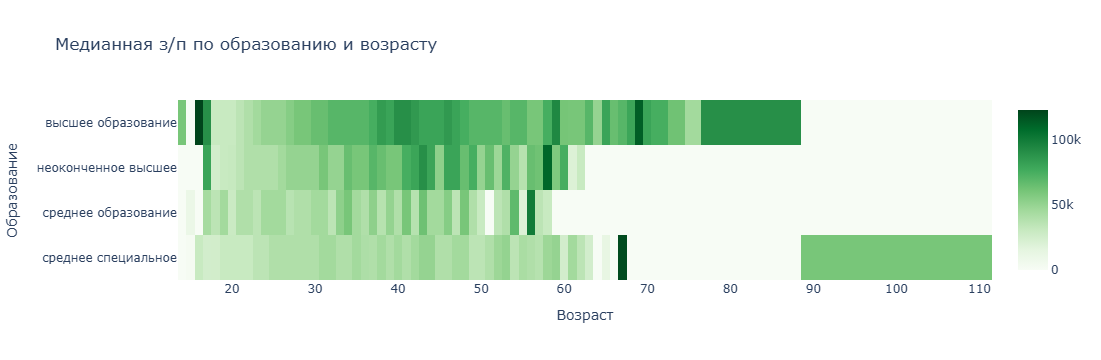

In [41]:
# ваш код здесь

pivot = df.pivot_table(
    index='Образование',
    columns='Возраст',
    values='ЗП (руб)',
    aggfunc='median',
    fill_value=0
)
fig = px.imshow(
    pivot,
    aspect='auto',
    color_continuous_scale='greens',
    title='Медианная з/п по образованию и возрасту'
)
fig.show()

### ваши выводы здесь
* Наиболее ценится высшее образование, так как оно необходимо в наукоемких отраслях;
* На втором месте "рабочие специальности", так как ценятся люди, которые умеют работать "руками".

8. Постройте **диаграмму рассеяния**, показывающую зависимость опыта работы (**"Опыт работы (месяц)"**) от возраста (**"Возраст"**). Опыт работы переведите из месяцев в года, чтобы признаки были в едином масштабе. Постройте на графике дополнительно прямую, проходящую через точки (0, 0) и (100, 100). Данная прямая соответствует значениям, когда опыт работы равен возрасту человека. Точки, лежащие на этой прямой и выше нее - аномалии в наших данных (опыт работы больше либо равен возрасту соискателя)

#### Сколько точек лежат строго выше построенной прямой? Так как точки могут сливаться с прямой, то для ответа на этот вопрос проще всего воспользоваться интерактивной визуализацией либо получить таблицу с наблюдениями, лежащими выше прямой с помощью фильтрации.

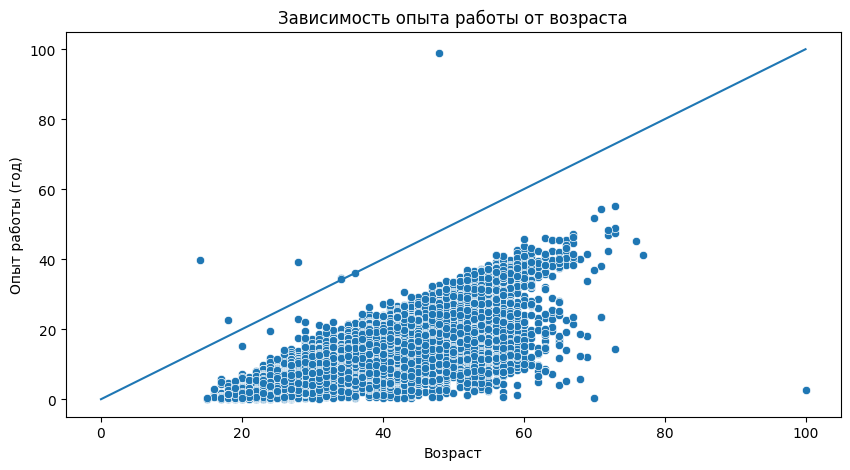

In [42]:
import matplotlib.pyplot as plt 

fig = plt.figure(figsize=(10, 5))
scatter_data = df.copy()
scatter_data['Опыт работы (год)'] = scatter_data['Опыт работы (месяц)']/12
sns.lineplot(x=[0, 100], y=[0, 100])
ax = sns.scatterplot(
    data=scatter_data, 
    x='Возраст',
    y='Опыт работы (год)',
)
ax.set_title('Зависимость опыта работы от возраста');

In [43]:
# ваш код здесь

ваши выводы здесь

**Дополнительные баллы**

Для получения 2 дополнительных баллов по разведывательному анализу постройте еще два любых содержательных графика или диаграммы, которые помогут проиллюстрировать влияние признаков/взаимосвязь между признаками/распределения признаков. Приведите выводы по ним. Желательно, чтобы в анализе участвовали признаки, которые мы создавали ранее в разделе "Преобразование данных".


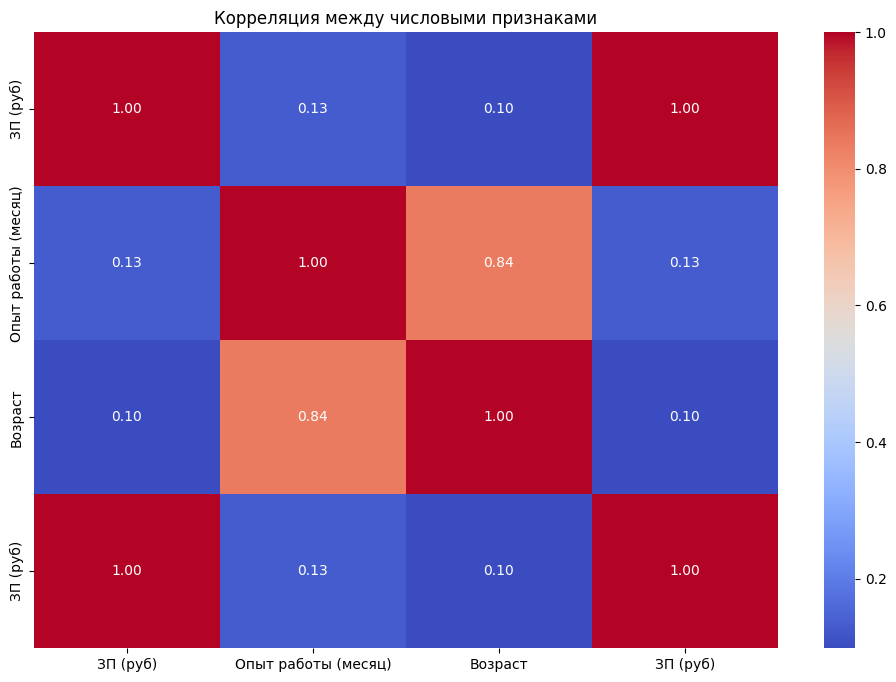

In [44]:
# График 1: Тепловая карта корреляций
plt.figure(figsize=(12, 8))
plt.title('Корреляция между числовыми признаками')

# Выбираем числовые признаки для анализа
numeric_features = ['ЗП (руб)', 'Опыт работы (месяц)', 'Возраст', 'ЗП (руб)']

# Создаем корреляционную матрицу
corr = df[numeric_features].corr()

# Визуализация
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()


### ваши выводы
* Наблюдается логическая и объяснимая корреляция между опытом работы и вощрастом (нельзя иметь опыт работы 10 лет в 20 летнем возрасте);
* Остальные корреляции не найдены

C:\Users\Александр\AppData\Local\Temp\ipykernel_6612\553647587.py:3: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




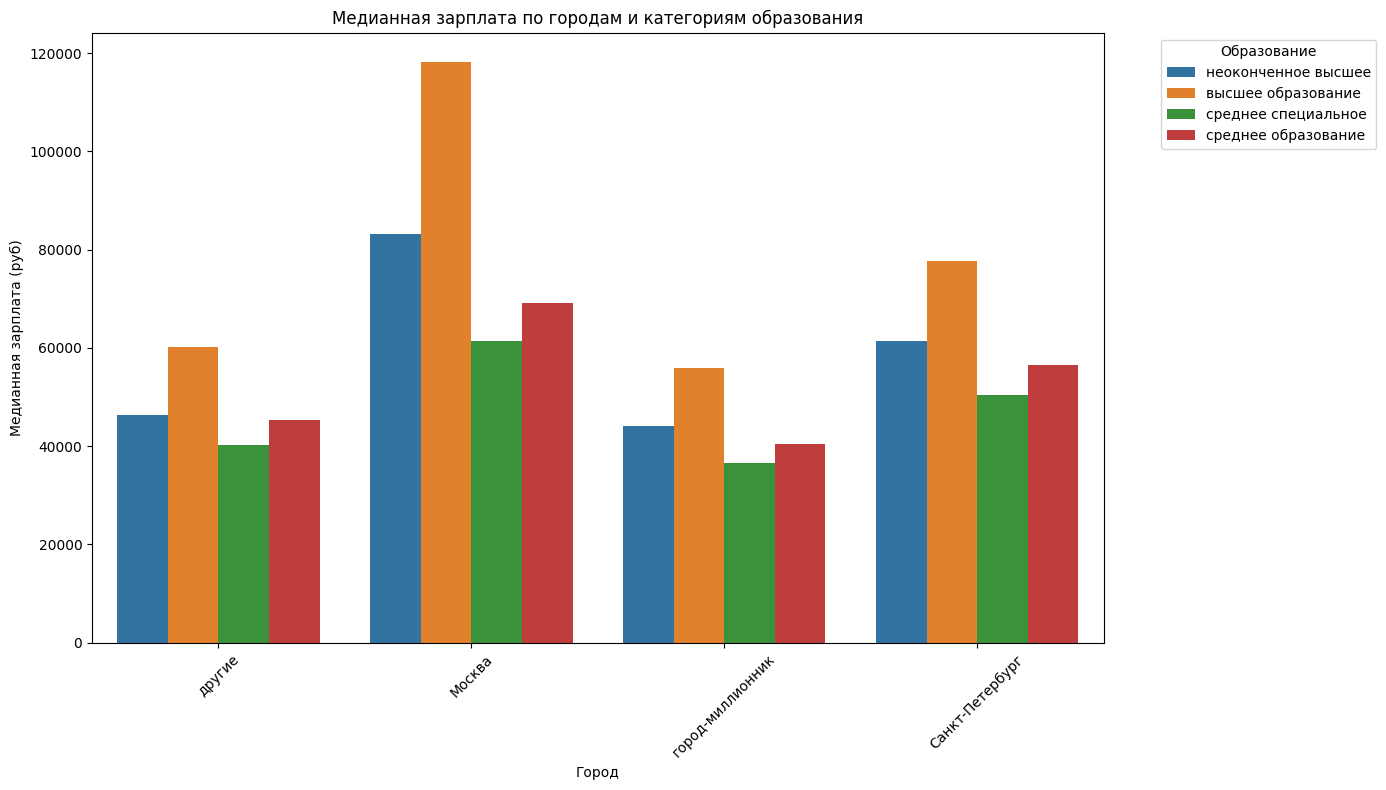

In [45]:
plt.figure(figsize=(14, 8))

sns.barplot(
    data=df,
    x='Город',
    y='ЗП (руб)',
    hue='Образование',
    ci=None
)

plt.title('Медианная зарплата по городам и категориям образования')
plt.ylabel('Медианная зарплата (руб)')
plt.xlabel('Город')
plt.legend(title='Образование', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ваши выводы
* В москве больше вакансий для людей с высшим образованием;
* Почти одинаковые медианы для всех городов у средних и неоконченных высших образований;
* Географический фактор по зарплатам остается ключевым

# Очистка данных

1. Начнем с дубликатов в наших данных. Найдите **полные дубликаты** в таблице с резюме и удалите их. 

In [46]:
df.duplicated().sum()

155

In [47]:
# ваш код здесь
df.duplicated().sum()

155

2. Займемся пропусками. Выведите информацию **о числе пропусков** в столбцах. 

In [48]:
# ваш код здесь
df['Опыт работы (месяц)'].isnull().sum()

170

3. Итак, у нас есть пропуски в 3ех столбцах: **"Опыт работы (месяц)"**, **"Последнее/нынешнее место работы"**, **"Последняя/нынешняя должность"**. Поступим следующим образом: удалите строки, где есть пропуск в столбцах с местом работы и должностью. Пропуски в столбце с опытом работы заполните **медианным** значением.

In [49]:
# ваш код здесь
df = df.dropna(
    subset=['Последнее/нынешнее место работы', 'Последняя/нынешняя должность']
)

In [50]:
median_experience = df['Опыт работы (месяц)'].median()
df['Опыт работы (месяц)'] = df['Опыт работы (месяц)'].fillna(median_experience)

In [51]:
round(df['Опыт работы (месяц)'].mean())

114

4. Мы добрались до ликвидации выбросов. Сначала очистим данные вручную. Удалите резюме, в которых указана заработная плата либо выше 1 млн. рублей, либо ниже 1 тыс. рублей.

In [52]:
# ваш код здесь

removed_high = len(df[df['ЗП (руб)'] > 1000000])
removed_low = len(df[df['ЗП (руб)'] < 1000])


print(f"Удалено записей с зарплатой выше 1 млн руб: {removed_high}")
print(f"Удалено записей с зарплатой ниже 1 тыс руб: {removed_low}")

Удалено записей с зарплатой выше 1 млн руб: 5
Удалено записей с зарплатой ниже 1 тыс руб: 84


In [53]:
df = df[(df['ЗП (руб)'] <= 1000000) & (df['ЗП (руб)'] >= 1000)]

5. В процессе разведывательного анализа мы обнаружили резюме, в которых **опыт работы в годах превышал возраст соискателя**. Найдите такие резюме и удалите их из данных


In [54]:
# ваш код здесь
anomalies = df[(df['Опыт работы (месяц)'] / 12) > df['Возраст']]
print( anomalies.shape[0])

# Удаляем эти записи из датасета
df = df[(df['Опыт работы (месяц)'] / 12) <= df['Возраст']]

7


6. В результате анализа мы обнаружили потенциальные выбросы в признаке **"Возраст"**. Это оказались резюме людей чересчур преклонного возраста для поиска работы. Попробуйте построить распределение признака в **логарифмическом масштабе**. Добавьте к графику линии, отображающие **среднее и границы интервала метода трех сигм**. Напомним, сделать это можно с помощью метода axvline. Например, для построение линии среднего будет иметь вид:

`histplot.axvline(log_age.mean(), color='k', lw=2)`

В какую сторону асимметрично логарифмическое распределение? Напишите об этом в комментарии к графику.
Найдите выбросы с помощью метода z-отклонения и удалите их из данных, используйте логарифмический масштаб. Давайте сделаем послабление на **1 сигму** (возьмите 4 сигмы) в **правую сторону**.

Выведите таблицу с полученными выбросами и оцените, с каким возрастом соискатели попадают под категорию выбросов?

Text(0.5, 1.0, 'Log Age Distribution')

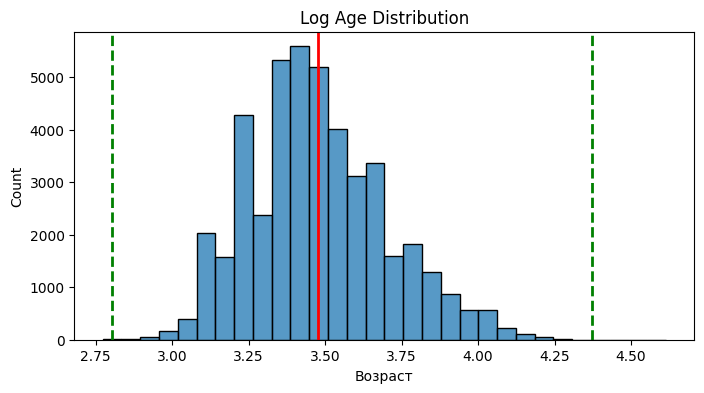

In [65]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
log_age = np.log(df['Возраст'] + 1)
histplot = sns.histplot(log_age, bins=30, ax=ax)
histplot.axvline(log_age.mean(), color='r', lw=2)
histplot.axvline(log_age.mean()+ 4 *log_age.std(), color='g', ls='--', lw=2)
histplot.axvline(log_age.mean()- 3 *log_age.std(), color='g', ls='--', lw=2)
histplot.set_title('Log Age Distribution')

In [58]:
def outliers_z_score(data, feature, log_scale=False):
    if log_scale:
        x = np.log(data[feature]+1)
    else:
        x = data[feature]
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - 3 * sigma
    upper_bound = mu + 4 * sigma
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

In [60]:
outliers, _ = outliers_z_score(df, 'Возраст', log_scale = True)
print(outliers.shape[0])

3


In [67]:
outliers['Возраст']

31137     15
32950     15
33654    100
Name: Возраст, dtype: int32

### ваш коммментарий здесь
* Лево сторонее смещение
* Большинство записей сконцетрированно по центру
